Dataset Understanding and Description:
For this task, I am using the Medical Cost Personal Dataset (insurance.csv).

1. Structure: After loading and cleaning the data, I confirmed there are no null values, making the data ready for processing.

2. Features: The data points being analyzed include:

Numerical: age, bmi, children, and the target charges.

Categorical: sex, smoker, and region (which were converted into numerical dummy variables: sex_male, smoker_yes, region_northwest, region_southeast, region_southwest).

In [1]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb

In [2]:
insfile=pd.read_csv("insurance.csv")

In [3]:
insfile.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insfile.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: xlabel='charges', ylabel='Count'>

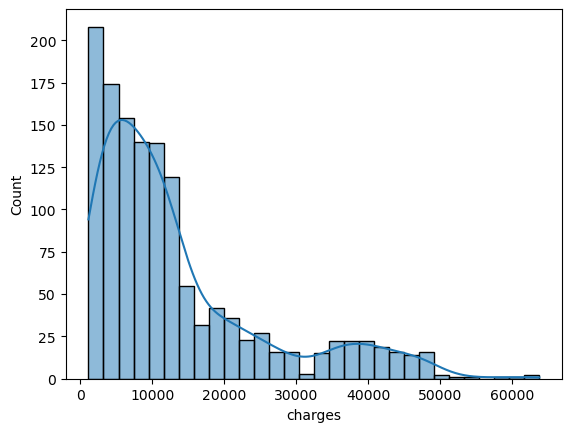

In [8]:
sb.histplot(x='charges',data=insfile,kde=True)

In [10]:
insfile.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [11]:
insfile_encoded=pd.get_dummies(data=insfile,drop_first=True)

In [12]:
insfile_encoded.dtypes

age                   int64
bmi                 float64
children              int64
charges             float64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

In [13]:
insfile_encoded.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

<Axes: >

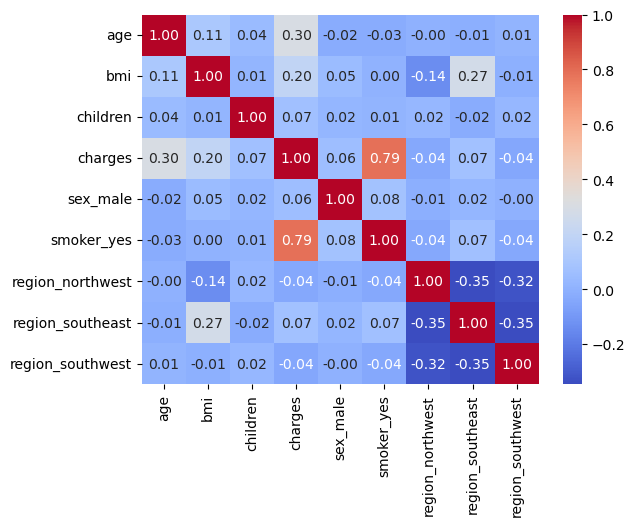

In [15]:
sb.heatmap(insfile_encoded.corr(), annot=True, cmap='coolwarm',fmt='.2f')

In [16]:
y=insfile_encoded['charges']
X=insfile_encoded.drop(columns='charges')

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Get predictions
predictions = model.predict(X_test)

Mean Absolute Error: $4181.19
R-squared Score: 0.7836


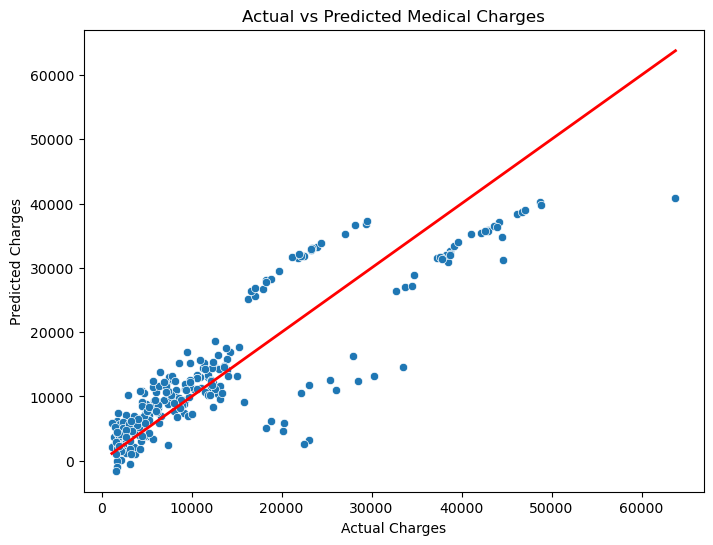

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Calculate the metrics
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"R-squared Score: {r2:.4f}")

# 2. Plot Actual vs Predicted
mp.figure(figsize=(8, 6))
sb.scatterplot(x=y_test, y=predictions)
mp.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Diagonal line
mp.xlabel('Actual Charges')
mp.ylabel('Predicted Charges')
mp.title('Actual vs Predicted Medical Charges')
mp.show()

Conclusion:






Model Evaluation & Business Conclusion

The Linear Regression model achieved an R-squared score of 0.7836, indicating a strong fit for predicting medical insurance charges. The Mean Absolute Error (MAE) of $4,181.19 shows the average deviation between predicted and actual costs.

Based on the correlation analysis, smoker status is the most significant factor affecting insurance charges, followed by age and BMI. The scatter plot of "Actual vs Predicted" charges shows that while the model is very accurate for lower-cost claims, it tends to underestimate some of the extremely high-cost outliers. For the insurance provider, this highlights that lifestyle choices, particularly smoking, are the primary drivers of financial risk.